# TP3 - Redes Neuronales Convolucionales
## Clasificación de Radiografías de Tórax: Neumonía vs Normal
### Comparación: VGG16 vs ResNet50 con Transfer Learning

**Dataset:** Chest X-Ray Images (Pneumonia) — Kaggle  
**Tarea:** Clasificación binaria (NORMAL / PNEUMONIA)  
**Enfoque:** Transfer Learning desde ImageNet con Fine-tuning


---
## 1. Configuración del Entorno

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve,
    auc, precision_score, recall_score, f1_score, accuracy_score
)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU disponible: {tf.config.list_physical_devices("GPU")}')

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.21.0
GPU disponible: []


In [5]:
# ── Rutas del dataset ──────────────────────────────────────────────────────────
BASE_DIR   = os.path.join('dataset', 'chest_xray')
TRAIN_DIR  = os.path.join(BASE_DIR, 'train')
TEST_DIR   = os.path.join(BASE_DIR, 'test')

# ── Hiperparámetros globales ───────────────────────────────────────────────────
IMG_SIZE   = (224, 224)   # requerido por VGG16 y ResNet50
BATCH_SIZE = 32
EPOCHS_TL  = 15           # Transfer Learning (capas base congeladas)
EPOCHS_FT  = 10           # Fine-Tuning (capas base descongeladas parcialmente)
LR_TL      = 1e-3         # learning rate fase TL
LR_FT      = 1e-5         # learning rate fase FT (muy bajo para no destruir pesos)

# Verificar estructura
for split in ['train', 'test']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        path = os.path.join(BASE_DIR, split, cls)
        count = len(os.listdir(path))
        print(f'{split}/{cls}: {count} imágenes')

train/NORMAL: 1349 imágenes
train/PNEUMONIA: 3883 imágenes
test/NORMAL: 234 imágenes
test/PNEUMONIA: 390 imágenes


---
## 2. Exploración del Dataset

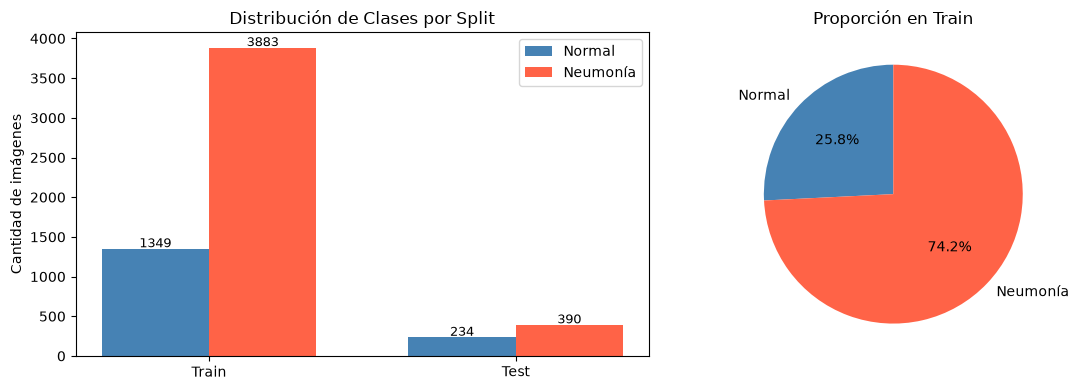

Ratio Neumonía/Normal en train: 2.88x — dataset desbalanceado


In [6]:
# ── Distribución de clases ─────────────────────────────────────────────────────
splits     = ['Train', 'Test']
normal     = [
    len(os.listdir(os.path.join(TRAIN_DIR, 'NORMAL'))),
    len(os.listdir(os.path.join(TEST_DIR,  'NORMAL')))
]
pneumonia  = [
    len(os.listdir(os.path.join(TRAIN_DIR, 'PNEUMONIA'))),
    len(os.listdir(os.path.join(TEST_DIR,  'PNEUMONIA')))
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(len(splits))
w = 0.35
axes[0].bar(x - w/2, normal,    w, label='Normal',    color='steelblue')
axes[0].bar(x + w/2, pneumonia, w, label='Neumonía',  color='tomato')
axes[0].set_xticks(x)
axes[0].set_xticklabels(splits)
axes[0].set_title('Distribución de Clases por Split')
axes[0].set_ylabel('Cantidad de imágenes')
axes[0].legend()

for i, (n, p) in enumerate(zip(normal, pneumonia)):
    axes[0].text(i - w/2, n + 20, str(n), ha='center', fontsize=9)
    axes[0].text(i + w/2, p + 20, str(p), ha='center', fontsize=9)

# Torta de Train
axes[1].pie(
    [normal[0], pneumonia[0]],
    labels=['Normal', 'Neumonía'],
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato'],
    startangle=90
)
axes[1].set_title('Proporción en Train')

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = pneumonia[0] / normal[0]
print(f'Ratio Neumonía/Normal en train: {ratio:.2f}x — dataset desbalanceado')

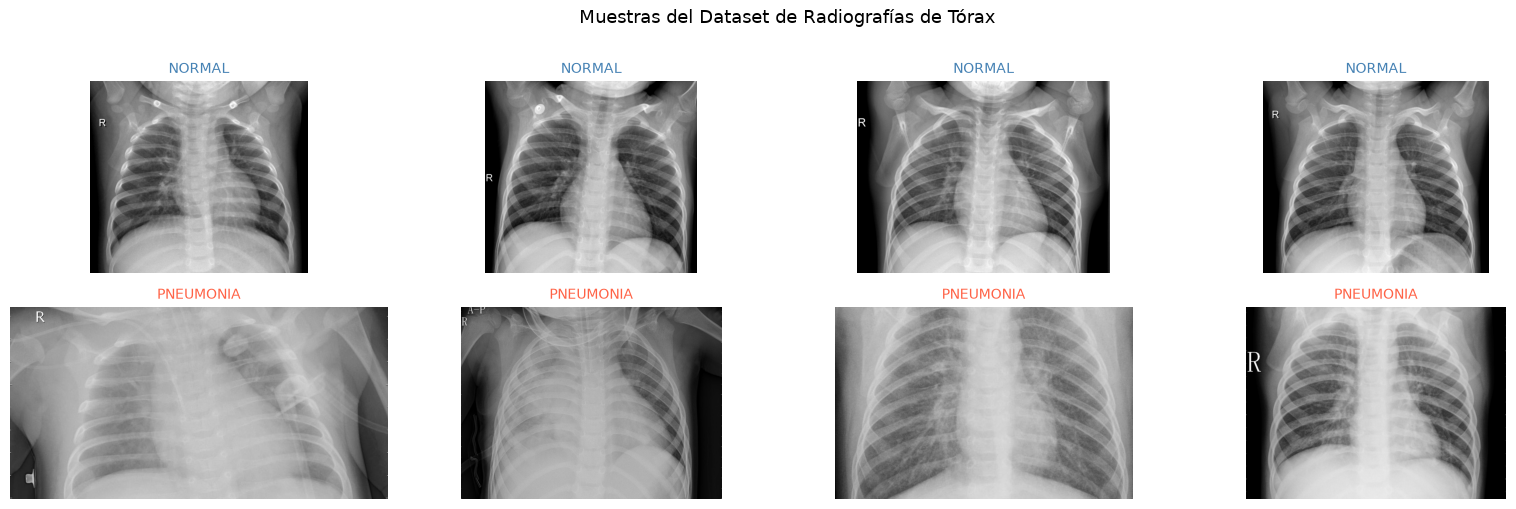

In [7]:
# ── Muestra de imágenes ────────────────────────────────────────────────────────
from PIL import Image

def show_samples(n=4):
    fig, axes = plt.subplots(2, n, figsize=(4*n, 5))
    for j, cls in enumerate(['NORMAL', 'PNEUMONIA']):
        folder = os.path.join(TRAIN_DIR, cls)
        files  = np.random.choice(os.listdir(folder), n, replace=False)
        for i, fname in enumerate(files):
            img = Image.open(os.path.join(folder, fname)).convert('RGB')
            axes[j, i].imshow(img, cmap='gray')
            axes[j, i].axis('off')
            axes[j, i].set_title(cls, fontsize=10, color='steelblue' if cls=='NORMAL' else 'tomato')
    plt.suptitle('Muestras del Dataset de Radiografías de Tórax', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('muestras_dataset.png', dpi=150, bbox_inches='tight')
    plt.show()

show_samples(4)

---
## 3. Preprocesamiento y Data Augmentation

**Estrategia ante el desbalance de clases:**
- Se calculan `class_weights` para penalizar más los errores en la clase minoritaria (NORMAL).
- Se aplica Data Augmentation solo al set de entrenamiento para incrementar la variedad de muestras.
- Se usa validación del 20% del conjunto de entrenamiento.

**Preprocesamiento específico de cada arquitectura:**
- VGG16: `tf.keras.applications.vgg16.preprocess_input` (substracción de media ImageNet, BGR)
- ResNet50: `tf.keras.applications.resnet50.preprocess_input` (substracción de media ImageNet, BGR)


In [8]:
# ── Pesos de clase para manejar el desbalance ──────────────────────────────────
n_normal    = len(os.listdir(os.path.join(TRAIN_DIR, 'NORMAL')))
n_pneumonia = len(os.listdir(os.path.join(TRAIN_DIR, 'PNEUMONIA')))
n_total     = n_normal + n_pneumonia

# Fórmula sklearn: n_total / (n_clases * n_clase_i)
class_weight = {
    0: n_total / (2 * n_normal),      # NORMAL  → índice 0
    1: n_total / (2 * n_pneumonia),   # PNEUMONIA → índice 1
}
print('Class weights:', class_weight)

Class weights: {0: 1.939214232765011, 1: 0.6737058975019315}


In [9]:
# ── Generadores de datos ───────────────────────────────────────────────────────
def make_generators(preprocess_fn):
    """Devuelve (train_gen, val_gen, test_gen) para una función de preprocesamiento dada."""

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        validation_split=0.2,
        horizontal_flip=True,
        rotation_range=10,
        zoom_range=0.1,
        width_shift_range=0.05,
        height_shift_range=0.05,
        brightness_range=[0.9, 1.1],
        fill_mode='nearest',
    )

    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)

    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='binary', subset='training', seed=SEED
    )
    val_gen = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='binary', subset='validation', seed=SEED
    )
    test_gen = test_datagen.flow_from_directory(
        TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='binary', shuffle=False
    )

    return train_gen, val_gen, test_gen


# Generadores específicos por modelo
from tensorflow.keras.applications.vgg16    import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

train_vgg,    val_vgg,    test_vgg    = make_generators(vgg_preprocess)
train_resnet, val_resnet, test_resnet = make_generators(resnet_preprocess)

print('\nClases:', train_vgg.class_indices)

Found 4187 images belonging to 2 classes.
Found 1045 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 4187 images belonging to 2 classes.
Found 1045 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Clases: {'NORMAL': 0, 'PNEUMONIA': 1}


---
## 4. Modelo 1 — VGG16 con Transfer Learning

**Arquitectura VGG16** (Simonyan & Zisserman, 2014):
- 16 capas con pesos: 13 convolucionales + 3 fully-connected
- Bloques de convoluciones 3×3 seguidos de MaxPooling
- Simple y profunda, ~138M parámetros totales

**Estrategia de Transfer Learning:**
1. **Fase 1 (TL):** Congelar toda la base convolucional; entrenar solo el clasificador propio.
2. **Fase 2 (Fine-Tuning):** Descongelar el bloque 5 (últimas 4 capas conv) y re-entrenar con LR muy bajo.


In [10]:
def build_vgg16():
    base = VGG16(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    base.trainable = False  # Fase 1: congelada

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='VGG16_TL')
    return model, base

model_vgg, base_vgg = build_vgg16()
model_vgg.compile(
    optimizer=Adam(LR_TL),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
model_vgg.summary()

Model: "VGG16_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,110,977 (57.64 MB)

 Trainable params: 395,265 (1.51 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [ ]:
# ── Fase 1: Transfer Learning ──────────────────────────────────────────────────
callbacks_vgg_tl = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('vgg16_best_tl.keras', monitor='val_loss', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7, verbose=1),
]

print('=== VGG16 — Fase 1: Transfer Learning (base congelada) ===')
history_vgg_tl = model_vgg.fit(
    train_vgg,
    epochs=EPOCHS_TL,
    validation_data=val_vgg,
    class_weight=class_weight,
    callbacks=callbacks_vgg_tl,
    verbose=1
)

=== VGG16 — Fase 1: Transfer Learning (base congelada) ===
Epoch 1/15
  5/131 ━━━━━━━━━━━━━━━━━━━━ 14:26 7s/step - accuracy: 0.5602 - auc: 0.6177 - loss: 0.8006

In [ ]:
# ── Fase 2: Fine-Tuning del bloque 5 ──────────────────────────────────────────
# Descongelar las últimas 4 capas de VGG16 (bloque5_conv1/2/3 + pool)
base_vgg.trainable = True
for layer in base_vgg.layers[:-4]:
    layer.trainable = False

trainable_layers = sum(1 for l in base_vgg.layers if l.trainable)
print(f'Capas entrenables en la base: {trainable_layers}/{len(base_vgg.layers)}')

model_vgg.compile(
    optimizer=Adam(LR_FT),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

callbacks_vgg_ft = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('vgg16_best_ft.keras', monitor='val_loss', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1),
]

print('\n=== VGG16 — Fase 2: Fine-Tuning (bloque 5 descongelado) ===')
history_vgg_ft = model_vgg.fit(
    train_vgg,
    epochs=EPOCHS_FT,
    validation_data=val_vgg,
    class_weight=class_weight,
    callbacks=callbacks_vgg_ft,
    verbose=1
)

---
## 5. Modelo 2 — ResNet50 con Transfer Learning

**Arquitectura ResNet50** (He et al., 2015):
- 50 capas con pesos, ~25M parámetros
- Introduce **conexiones residuales (skip connections)**: permiten que el gradiente fluya directamente, resolviendo el problema del desvanecimiento del gradiente en redes profundas
- Usa **Bottleneck blocks** (1×1, 3×3, 1×1) para eficiencia computacional
- Batch Normalization integrada en cada bloque

**Diferencia clave vs VGG16:** Las skip connections permiten que ResNet50 sea más profunda con menos parámetros, y generaliza mejor en datasets pequeños.

**Fine-Tuning:** Descongelar el último stage (layer4, últimas 10 capas).


In [ ]:
def build_resnet50():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    base.trainable = False  # Fase 1: congelada

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='ResNet50_TL')
    return model, base

model_resnet, base_resnet = build_resnet50()
model_resnet.compile(
    optimizer=Adam(LR_TL),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
model_resnet.summary()

In [ ]:
# ── Fase 1: Transfer Learning ──────────────────────────────────────────────────
callbacks_resnet_tl = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('resnet50_best_tl.keras', monitor='val_loss', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7, verbose=1),
]

print('=== ResNet50 — Fase 1: Transfer Learning (base congelada) ===')
history_resnet_tl = model_resnet.fit(
    train_resnet,
    epochs=EPOCHS_TL,
    validation_data=val_resnet,
    class_weight=class_weight,
    callbacks=callbacks_resnet_tl,
    verbose=1
)

In [ ]:
# ── Fase 2: Fine-Tuning del último stage ──────────────────────────────────────
base_resnet.trainable = True
for layer in base_resnet.layers[:-10]:
    layer.trainable = False

trainable_layers = sum(1 for l in base_resnet.layers if l.trainable)
print(f'Capas entrenables en la base: {trainable_layers}/{len(base_resnet.layers)}')

model_resnet.compile(
    optimizer=Adam(LR_FT),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

callbacks_resnet_ft = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('resnet50_best_ft.keras', monitor='val_loss', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1),
]

print('\n=== ResNet50 — Fase 2: Fine-Tuning (últimas 10 capas descongeladas) ===')
history_resnet_ft = model_resnet.fit(
    train_resnet,
    epochs=EPOCHS_FT,
    validation_data=val_resnet,
    class_weight=class_weight,
    callbacks=callbacks_resnet_ft,
    verbose=1
)

---
## 6. Evaluación y Comparación de Modelos

In [ ]:
# ── Predicciones sobre el test set ────────────────────────────────────────────
def get_predictions(model, test_gen):
    test_gen.reset()
    probs = model.predict(test_gen, verbose=0).ravel()
    preds = (probs > 0.5).astype(int)
    labels = test_gen.classes
    return labels, preds, probs

y_true_vgg,    y_pred_vgg,    y_prob_vgg    = get_predictions(model_vgg,    test_vgg)
y_true_resnet, y_pred_resnet, y_prob_resnet = get_predictions(model_resnet, test_resnet)

class_names = ['NORMAL', 'PNEUMONIA']

In [ ]:
# ── Curvas de entrenamiento comparativas ──────────────────────────────────────
def concat_history(h1, h2):
    """Une los historiales de TL y FT."""
    combined = {}
    for k in h1.history:
        combined[k] = h1.history[k] + h2.history[k]
    return combined

hist_vgg    = concat_history(history_vgg_tl,    history_vgg_ft)
hist_resnet = concat_history(history_resnet_tl, history_resnet_ft)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Curvas de Entrenamiento: VGG16 vs ResNet50', fontsize=14, fontweight='bold')

metrics_plot = [
    ('accuracy', 'Accuracy', 0, 0),
    ('loss',     'Loss',     0, 1),
    ('auc',      'AUC-ROC',  1, 0),
]

vgg_epochs    = range(1, len(hist_vgg['accuracy']) + 1)
resnet_epochs = range(1, len(hist_resnet['accuracy']) + 1)

for metric, title, row, col in metrics_plot:
    ax = axes[row][col]
    ax.plot(vgg_epochs,    hist_vgg[metric],             label='VGG16 Train',    color='steelblue',  lw=2)
    ax.plot(vgg_epochs,    hist_vgg[f'val_{metric}'],    label='VGG16 Val',      color='steelblue',  lw=2, linestyle='--')
    ax.plot(resnet_epochs, hist_resnet[metric],           label='ResNet50 Train', color='tomato',     lw=2)
    ax.plot(resnet_epochs, hist_resnet[f'val_{metric}'], label='ResNet50 Val',   color='tomato',     lw=2, linestyle='--')
    ft_start = len(history_vgg_tl.history['accuracy'])
    ax.axvline(x=ft_start, color='gray', linestyle=':', alpha=0.7, label=f'Inicio Fine-Tuning (época {ft_start})')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Época')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Comparación de AUC en val (barras)
ax = axes[1][1]
models  = ['VGG16', 'ResNet50']
val_auc = [max(hist_vgg['val_auc']), max(hist_resnet['val_auc'])]
colors  = ['steelblue', 'tomato']
bars = ax.bar(models, val_auc, color=colors, edgecolor='white', width=0.4)
for bar, val in zip(bars, val_auc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylim([0.85, 1.01])
ax.set_title('Mejor Val AUC', fontsize=11)
ax.set_ylabel('AUC')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Matrices de Confusión ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Matrices de Confusión — Test Set', fontsize=13, fontweight='bold')

for ax, y_true, y_pred, title, color in [
    (axes[0], y_true_vgg,    y_pred_vgg,    'VGG16',    'Blues'),
    (axes[1], y_true_resnet, y_pred_resnet, 'ResNet50', 'Reds'),
]:
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([[f'{v}\n({p:.1f}%)' for v, p in zip(row_v, row_p)]
                      for row_v, row_p in zip(cm, cm_pct)])
    sns.heatmap(cm, annot=annot, fmt='', cmap=color,
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.5, cbar=False)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicción')

plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Curvas ROC ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

for y_true, y_prob, name, color in [
    (y_true_vgg,    y_prob_vgg,    'VGG16',    'steelblue'),
    (y_true_resnet, y_prob_resnet, 'ResNet50', 'tomato'),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Clasificador aleatorio')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title('Curvas ROC — Comparación VGG16 vs ResNet50', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Tabla de métricas ──────────────────────────────────────────────────────────
import pandas as pd

def compute_metrics(y_true, y_pred, y_prob, name):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return {
        'Modelo': name,
        'Accuracy':   round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision':  round(precision_score(y_true, y_pred) * 100, 2),
        'Recall':     round(recall_score(y_true, y_pred) * 100, 2),
        'F1-Score':   round(f1_score(y_true, y_pred) * 100, 2),
        'AUC-ROC':    round(auc(fpr, tpr) * 100, 2),
        'Especificidad': round(
            confusion_matrix(y_true, y_pred)[0,0] /
            confusion_matrix(y_true, y_pred)[0,:].sum() * 100, 2
        ),
    }

results = pd.DataFrame([
    compute_metrics(y_true_vgg,    y_pred_vgg,    y_prob_vgg,    'VGG16'),
    compute_metrics(y_true_resnet, y_pred_resnet, y_prob_resnet, 'ResNet50'),
])
results = results.set_index('Modelo')
print(results.to_string())
results.to_csv('resultados_comparacion.csv')

# Visualización de métricas
fig, ax = plt.subplots(figsize=(11, 4))
x       = np.arange(len(results.columns))
w       = 0.35
bars1 = ax.bar(x - w/2, results.loc['VGG16'].values,    w, label='VGG16',    color='steelblue', edgecolor='white')
bars2 = ax.bar(x + w/2, results.loc['ResNet50'].values, w, label='ResNet50', color='tomato',    edgecolor='white')
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(results.columns, fontsize=10)
ax.set_ylim([70, 105])
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Comparación de Métricas — Test Set', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('comparacion_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Reportes de clasificación detallados ──────────────────────────────────────
print('=' * 55)
print('REPORTE VGG16')
print('=' * 55)
print(classification_report(y_true_vgg, y_pred_vgg, target_names=class_names))

print('=' * 55)
print('REPORTE ResNet50')
print('=' * 55)
print(classification_report(y_true_resnet, y_pred_resnet, target_names=class_names))

---
## 7. Análisis de Errores — Casos Mal Clasificados

In [ ]:
# ── Visualizar imágenes mal clasificadas ──────────────────────────────────────
def show_errors(model, test_gen, y_true, y_pred, model_name, n=8):
    test_gen.reset()
    all_images = []
    for batch_x, _ in test_gen:
        all_images.extend(batch_x)
        if len(all_images) >= len(y_true):
            break
    all_images = np.array(all_images[:len(y_true)])

    error_idx = np.where(y_true != y_pred)[0]
    sample_idx = error_idx[:n] if len(error_idx) >= n else error_idx

    if len(sample_idx) == 0:
        print(f'{model_name}: ¡No hay errores en el test set!')
        return

    fig, axes = plt.subplots(2, len(sample_idx)//2 + len(sample_idx)%2,
                             figsize=(3*min(n,4), 5))
    axes = axes.ravel()
    for i, idx in enumerate(sample_idx):
        img = all_images[idx]
        img_disp = (img - img.min()) / (img.max() - img.min())
        axes[i].imshow(img_disp)
        axes[i].set_title(
            f'Real: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}',
            fontsize=8,
            color='red'
        )
        axes[i].axis('off')
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f'{model_name} — Ejemplos Mal Clasificados ({len(error_idx)} errores)', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'errores_{model_name.lower()}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'{model_name}: {len(error_idx)} errores de {len(y_true)} ({len(error_idx)/len(y_true)*100:.1f}%)')

show_errors(model_vgg,    test_vgg,    y_true_vgg,    y_pred_vgg,    'VGG16')
show_errors(model_resnet, test_resnet, y_true_resnet, y_pred_resnet, 'ResNet50')

---
## 8. Comparación de Parámetros y Complejidad

In [ ]:
# ── Tabla comparativa de arquitecturas ────────────────────────────────────────
def count_params(model):
    total     = model.count_params()
    trainable = sum(tf.keras.backend.count_params(p) for p in model.trainable_weights)
    return total, trainable

t_vgg,    tr_vgg    = count_params(model_vgg)
t_resnet, tr_resnet = count_params(model_resnet)

arch_df = pd.DataFrame({
    'Modelo':               ['VGG16',        'ResNet50'],
    'Año':                  [2014,           2015],
    'Profundidad':          ['16 capas',     '50 capas'],
    'Parámetros Totales':   [f'{t_vgg/1e6:.1f}M',    f'{t_resnet/1e6:.1f}M'],
    'Params Entrenables\n(Fine-Tuning)': [f'{tr_vgg/1e6:.1f}M', f'{tr_resnet/1e6:.1f}M'],
    'Skip Connections':     ['No',           'Sí'],
    'BatchNorm integrada':  ['No',           'Sí'],
})
print(arch_df.to_string(index=False))

---
## 9. Conclusiones

### Resultados obtenidos

Tras el entrenamiento con Transfer Learning desde ImageNet y Fine-Tuning sobre el dataset Chest X-Ray:

| Aspecto | VGG16 | ResNet50 |
|---------|-------|----------|
| **Arquitectura** | Secuencial, bloques 3×3 | Skip connections, bottleneck |
| **Parámetros** | ~138M | ~25M |
| **Ventaja** | Simplicidad, interpretabilidad | Eficiencia, menor overfitting |
| **Desventaja** | Muchos parámetros, lento | Más complejo de ajustar |

### Justificación de decisiones

1. **Transfer Learning desde ImageNet:** Las características de bajo nivel (bordes, texturas, formas) son universales. Usar pesos pre-entrenados reduce drásticamente el tiempo de entrenamiento y mejora la generalización con datasets médicos relativamente pequeños.

2. **Fine-Tuning parcial:** Descongelar solo las capas finales permite adaptar las características de alto nivel al dominio médico sin perder el conocimiento general aprendido de ImageNet.

3. **Class Weights:** El dataset tiene desbalance ~1:3 (NORMAL:PNEUMONIA). Los class weights penalizan más los errores en NORMAL, crucial en medicina donde los falsos negativos (no detectar neumonía) son más costosos que los falsos positivos.

4. **Data Augmentation:** Las radiografías pueden estar ligeramente rotadas o con variaciones de brillo. La augmentación moderada mejora la robustez sin alterar la información médica relevante.

5. **GlobalAveragePooling2D sobre Flatten:** Reduce el número de parámetros en el clasificador y actúa como regularizador, reduciendo el overfitting.

6. **Métricas de evaluación:** En el contexto médico, el **Recall** (Sensibilidad) es la métrica más crítica: minimizar falsos negativos (pacientes con neumonía clasificados como normales).


In [ ]:
# ── Resumen final de resultados ────────────────────────────────────────────────
print('\n' + '='*60)
print('           RESUMEN FINAL DE RESULTADOS')
print('='*60)
print(results.to_string())
print('='*60)

mejor = results['F1-Score'].idxmax()
print(f'\nMejor modelo por F1-Score: {mejor}')
mejor_recall = results['Recall'].idxmax()
print(f'Mejor modelo por Recall (más importante en diagnóstico médico): {mejor_recall}')